In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_squared_error,log_loss
from tqdm import tqdm_notebook
import seaborn as sns
import imageio
import time
from IPython.display import HTML

from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import make_blobs

# Test Vectorisation

In [20]:
N = 100
M = 200
a = np.random.randn(N,M)
b = np.random.randn(N,M)
c = np.zeros((N,M))
# print(a,b,c)

In [21]:
%%time
for i in range(N):
    for j in range(M):
        c[i,j] = a[i,j] + b[i,j]

CPU times: total: 15.6 ms
Wall time: 7.36 ms


In [22]:
%%time
c = a+b

CPU times: total: 15.6 ms
Wall time: 230 μs


In [23]:
%%time
for i in range(N):
    for j in range(M):
        c[i,j]  = np.sin(a[i,j])

CPU times: total: 15.6 ms
Wall time: 20.8 ms


In [24]:
%%time
c = np.sin(a)

CPU times: total: 0 ns
Wall time: 192 μs


# Generate Data

In [25]:
data , labels = make_blobs(n_samples=1000,centers=4,n_features=2,random_state=0)
print(data.shape,labels.shape)

(1000, 2) (1000,)


In [26]:
my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("",["red","yellow","green"])

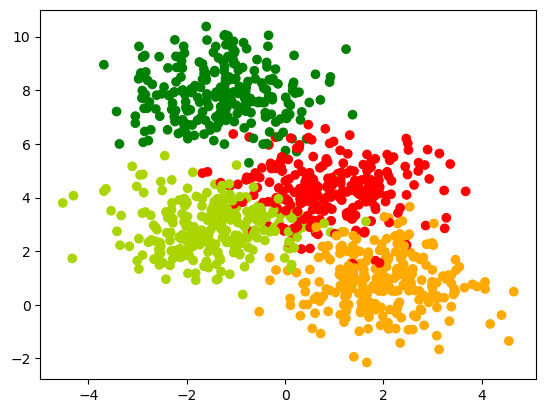

In [27]:
plt.scatter(data[:,0],data[:,1],c=labels,cmap=my_cmap)
plt.show()

In [28]:
labels_orig = labels
labels = np.mod(labels_orig,2)

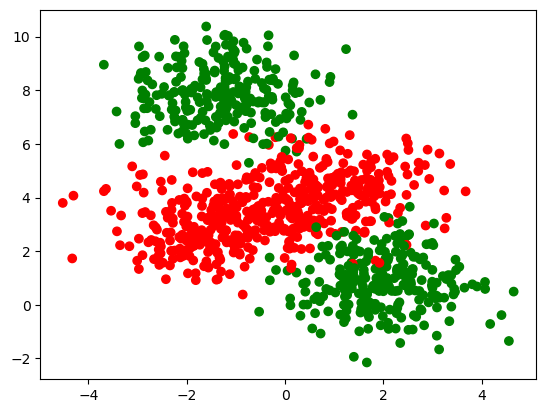

In [29]:
plt.scatter(data[:,0],data[:,1],c=labels,cmap=my_cmap)
plt.show()

# Multiclass Classification

In [30]:
X_train , X_val,Y_train,Y_val = train_test_split(data,labels,stratify=labels,random_state=0)
print(X_train.shape,X_val.shape,labels_orig.shape)

(750, 2) (250, 2) (1000,)


In [31]:
enc = OneHotEncoder()
y_OH_train = enc.fit_transform(np.expand_dims(Y_train,1)).toarray()
y_OH_val = enc.fit_transform(np.expand_dims(Y_val,1)).toarray()
print(y_OH_train.shape,y_OH_val.shape)

(750, 2) (250, 2)


In [32]:
W1 = np.random.randn(2,2)
W2 = np.random.randn(2,4)
print(W2)

[[-1.36413723  0.87626462  1.5098201   1.4078962 ]
 [ 0.25954711 -1.04219821 -0.31702274  0.78193497]]


# Scalar Version

In [33]:
class FF_Multiclass_Scalar:
    
    def __init__(self) -> None:
        self.w1 = W1[0][0].copy()
        self.w2 = W1[1][0].copy()
        self.w3 = W1[0][1].copy()
        self.w4 = W1[1][1].copy()
        self.w5 = W2[0][0].copy()
        self.w6 = W2[1][0].copy()
        self.w7 = W2[0][1].copy()
        self.w8 = W2[1][1].copy()
        self.w9 = W2[0][2].copy()
        self.w10 = W2[1][2].copy()
        self.w11 = W2[0][3].copy()
        self.w12 = W2[1][3].copy()
        self.b1 = 0
        self.b2 = 0
        self.b3 = 0
        self.b4 = 0
        self.b5 = 0
        self.b6 = 0
    def sigmoid(self,x):
        return np.where(x>=0,1.0/(1.0+np.exp(-x)),np.exp(x)/(1.0+np.exp(x)))
    def forward_pass(self,x):
        #input layer
        self.x1,self.x2 = x
        
        #hidden layer
        self.a1 = self.w1 * self.x1 + self.w2 * self.x2 + self.b1
        self.a2 = self.w3 * self.x1 + self.w4 * self.x2 + self.b2
        self.h1 = self.sigmoid(self.a1)
        self.h2 = self.sigmoid(self.a2)
        
        #output layer
        self.a3 = self.w5*self.h1 + self.w6*self.h2 + self.b3
        self.a4 = self.w7*self.h1 + self.w8*self.h2 + self.b4
        self.a5 = self.w9*self.h1 + self.w10*self.h2 +self.b5
        self.a6 = self.w11*self.h1 + self.w12*self.h2 +self.b6
        sum_exps = np.sum([np.exp(self.a3),np.exp(self.a4),np.exp(self.a5),np.exp(self.a6)])
        self.h3 = np.exp(self.a3) / sum_exps
        self.h4 = np.exp(self.a4) / sum_exps
        self.h5 = np.exp(self.a5) / sum_exps
        self.h6 = np.exp(self.a6) / sum_exps
        
        return np.array([self.h3,self.h4,self.h5,self.h6])
    
    def grad(self,x,y):
        self.forward_pass(x)
        self.y1,self.y2,self.y3,self.y4 = y
        
        
        self.da3 = (self.h3-self.y1)
        self.da4 = (self.h4-self.y2)
        self.da5 = (self.h5-self.y3)
        self.da6 = (self.h6-self.y4)
        
        self.dw5 = self.da3*self.h1
        self.dw6 = self.da3*self.h2
        self.db3 = self.da3
        
        self.dw7 = self.da4*self.h1
        self.dw8 = self.da4*self.h2
        self.db3 = self.da4
        
        self.dw9 = self.da5*self.h1
        self.dw10 = self.da5*self.h2
        self.db3 = self.da5
        
        self.dw11 = self.da6*self.h1
        self.dw12 = self.da6*self.h2
        self.db3 = self.da6
        
        self.dh1 = self.da3*self.w5 +self.da4*self.w7 + self.da5*self.w9
        self.dh2 = self.da3*self.w6 +self.da4*self.w8 + self.da5*self.w10
        
        self.da1 = self.dh1*self.h1*(1-self.h1)
        self.da2 = self.dh2*self.h2*(1-self.h2)
        
        self.dw1 = self.da1*self.x1
        self.dw2 = self.da2*self.x2
        self.db1 = self.da1
        
        self.dw3 = self.da2*self.x1
        self.dw4 = self.da2*self.x2
        self.db2 = self.da2
        
    def fit(self,X,Y,epochs=1,learning_rate=1,display_loss=False,initialise=True):
        if display_loss:
            loss ={}
        for i in tqdm_notebook(range(epochs),total=epochs,unit="epoch"):
            dw1,dw2,dw3,dw4,dw5,dw6,dw7,dw8,dw9,dw10,dw11,dw12,db1,db2,db3 = [0]*15
            for x,y in zip(X,Y):
                self.grad(x,y)
                dw1 += self.dw1
                dw2 += self.dw2
                dw3 += self.dw3
                dw4 += self.dw4
                dw5 += self.dw5
                dw6 += self.dw6
                dw7 += self.dw7
                dw8 += self.dw8
                dw9 += self.dw9
                dw10 += self.dw10
                dw11 += self.dw11
                dw12 += self.dw12
                db1 += self.db1
                db2 += self.db2
                db3 += self.db3
        
            m = X.shape[0]
            self.w1 -= learning_rate*dw1/m
            self.w2 -= learning_rate*dw2/m
            self.w3 -= learning_rate*dw3/m
            self.w4 -= learning_rate*dw4/m
            self.w5 -= learning_rate*dw5/m
            self.w6 -= learning_rate*dw6/m
            self.w7 -= learning_rate*dw7/m
            self.w8 -= learning_rate*dw8/m
            self.w9 -= learning_rate*dw9/m
            self.w10 -= learning_rate*dw10/m
            self.w11 -= learning_rate*dw11/m
            self.w12 -= learning_rate*dw12/m
            self.b1 -= learning_rate*db1/m
            self.b2 -= learning_rate*db2/m
            self.b3 -= learning_rate*db3/m
            
            if display_loss:
                Y_pred = self.predict(X)
                loss[i] = log_loss(np.argmax(Y,axis=1),Y_pred)
                
            # if display_loss:
            #     plt.plot(loss.values())
            #     plt.xlabel("epochs")
            #     plt.ylabel("Mean Squared Error")
                
            # plt.show()
            
        def predict(self,X):
            Y_pred = []
            for x in X:
                y_pred = self.forward_pass(x)
                Y_pred.append(y_pred)
            return np.array(Y_pred)
    

# Vectorisation

In [ ]:
class FF_Multiclass_Vector:
    
    def __init__(self) -> None:
        self.W1 = W1.copy()
        self.W2 = W2.copy()
        self.B1 = np.zeros((1,2))
        self.B2 = np.zeros((1,4))
    def sigmoid(self,x):
        return np.where(x>=0,1.0/(1.0+np.exp(-x)),np.exp(x)/(1.0+np.exp(x)))
    def softmax(self,x):
        exps = np.exp(x)
        return exps / np.sum(exps)
    def forward_pass(self,x):
        x = x.reshape(1,-1)
        self.A1 = np.matmul(x,self.W1) + self.B1
        self.H1 = self.sigmoid(self.A1)
        self.A2 = np.matmul(self.H1,self.W2) + self.B2
        self.H2 = self.sigmoid(self.A2)
        return self.H2
    def grad_sigmoid(self,x):
        return x * (1-x)
    def grad(self,x,y):
        self.forward_pass(x)
        x = x.reshape(1,-1)
        y = y.reshape(1,-1)
        
        self.dA2 = self.H2 - y
        
        self.dW2 = np.matmul(self.H1.T,self.dA2)
        self.B2 = self.dA2
        self.dH1 = np.matmul(self.dA2,self.W2.T)
        self.dA1 = np.multiply(self.dH1,self.grad_sigmoid(self.H1))
        
        self.dW1 = np.matmul(x.T,self.dA1)
        self.dB1 = self.dA1
        
    def fit(self,X,Y,epochs=1,learning_rate=1,display_loss=False):
        if display_loss:
            loss ={}
        for i in tqdm_notebook(range(epochs),total=epochs,unit="epochs",display_loss=False):
            dW1 = np.zeros((2,2))
            dW2 = np.zeros((2,4))
            dB1 = np.zeros((1,2))
            dB2 = np.zeros((1,4))
            
            for i in zip(X,Y):
                self.grad(X,Y)
                dW1 += self.dW1
                dW2 += self.dW2
                dB1 += self.dB1
                dB2 += self.dB2 
            m = X.shape[0]
            self.W2 -= learning_rate * (dW2/m)
            self.B2 -= learning_rate * (dB2/m)
            self.W1 -= learning_rate * (dW1/m)
            self.B1 -= learning_rate * (dB1/m)
            
            if display_loss:
                Y_pred = self.predict(X)
                loss[i] = log_loss(np.argmax(Y,axis=1),Y_pred)
                
        if display_loss:
            plt.plot(loss.values())
            plt.xlabel('Epochs')
            plt.ylabel('Log loss')
            plt.show()
    def predict(self,X):
        Y_pred =[]
        for x in X :
            y_pred = self.forward_pass(x)
            Y_pred.append(y_pred)
        
        return np.array(Y_pred).squeeze()